# ImmoVision 360 — Analyse Exploratoire des Données (EDA)

**Projet** : Diagnostic de l'impact d'Airbnb sur le quartier de l'Élysée (Paris)  
**Commanditaire** : Mairie de Paris  
**Données** : Table `elysee_tabular` — 2 626 annonces, 8 variables  
**Source** : Base de données PostgreSQL `immovision`  

---

## Rappel des 3 hypothèses de recherche

| # | Hypothèse | Question |
|---|---|---|
| A | **Économique** ("Machine à Cash") | Est-ce une économie de partage ou une industrie hôtelière masquée ? |
| B | **Sociale** (Déshumanisation) | Le lien social se brise-t-il au profit de processus automatisés ? |
| C | **Visuelle** (Standardisation) | Les logements sont-ils devenus des produits financiers stériles ? |

---
## 0. Chargement des données et préparation

In [1]:
# === Imports ===
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print('Bibliothèques chargées avec succès.')

Bibliothèques chargées avec succès.


### Connexion à la base de données PostgreSQL `immovision`

Les données sont chargées directement depuis la table `elysee_tabular` de la base **PostgreSQL** `immovision`.  
Les identifiants de connexion sont lus depuis le fichier `.env`.

> Si PostgreSQL n'est pas disponible, un fallback vers le CSV du DataWarehouse est prévu.

In [2]:
# === Chargement depuis PostgreSQL (base immovision) ===
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv('.env')

DB_USER = os.getenv('DB_USER', 'postgres')
DB_PASSWORD = os.getenv('DB_PASSWORD', '')
DB_HOST = os.getenv('DB_HOST', 'localhost')
DB_PORT = os.getenv('DB_PORT', '5432')
DB_NAME = os.getenv('DB_NAME', 'immovision')

try:
    engine = create_engine(f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')
    df = pd.read_sql('SELECT * FROM elysee_tabular', engine)
    print(f'[OK] Données chargées depuis PostgreSQL ({DB_NAME}) : {df.shape[0]} lignes × {df.shape[1]} colonnes')
    print(f'     Table : elysee_tabular')
    print(f'     Connexion : {DB_USER}@{DB_HOST}:{DB_PORT}/{DB_NAME}')
    SOURCE = 'PostgreSQL'
except Exception as e:
    print(f'[WARN] Connexion PostgreSQL échouée : {e}')
    print('[WARN] Fallback vers le CSV du DataWarehouse...')
    CSV_PATH = os.path.join('DataWarehouse', 'postgres', 'elysee_tabular.csv')
    df = pd.read_csv(CSV_PATH)
    print(f'[OK] Données chargées depuis CSV : {df.shape[0]} lignes × {df.shape[1]} colonnes')
    SOURCE = 'CSV'

print(f'\nSource : {SOURCE}')
print(f'Colonnes : {list(df.columns)}')
df.head()

[OK] Données chargées depuis PostgreSQL (immovision) : 2625 lignes × 8 colonnes
     Table : elysee_tabular
     Connexion : postgres@localhost:5432/immovision

Source : PostgreSQL
Colonnes : ['id', 'calculated_host_listings_count', 'availability_365', 'host_response_rate_num', 'room_type_code', 'host_response_time_code', 'standardization_score', 'neighborhood_impact_score']


,id,calculated_host_listings_count,availability_365,host_response_rate_num,room_type_code,host_response_time_code,standardization_score,neighborhood_impact_score
0,2871271,1,96,100.0,2,0.0,1,1
1,2785692,1,176,NaN,1,NaN,-1,-1
2,2892435,2,299,100.0,2,0.0,-1,-1
3,3015969,1,0,NaN,1,NaN,1,1
4,3126320,1,53,NaN,2,NaN,1,1


In [3]:
# === Traitement des valeurs manquantes ===
# Consigne du cours : remplacer les NaN par -1
# Convention : -1 signifie "information non disponible"
# ATTENTION : à distinguer des 0 métier (ex. availability_365 = 0 = logement fermé)

print('=== Valeurs manquantes AVANT traitement ===')
print(df.isnull().sum())
print(f'\nTotal NaN : {df.isnull().sum().sum()}')

df = df.fillna(-1)

print('\n=== Valeurs manquantes APRÈS traitement ===')
print(df.isnull().sum())
print('\nNote : -1 = information non disponible (NaN remplacé)')

=== Valeurs manquantes AVANT traitement ===
id                                  0
calculated_host_listings_count      0
availability_365                    0
host_response_rate_num            681
room_type_code                      0
host_response_time_code           681
standardization_score               0
neighborhood_impact_score           0
dtype: int64

Total NaN : 1362

=== Valeurs manquantes APRÈS traitement ===
id                                0
calculated_host_listings_count    0
availability_365                  0
host_response_rate_num            0
room_type_code                    0
host_response_time_code           0
standardization_score             0
neighborhood_impact_score         0
dtype: int64

Note : -1 = information non disponible (NaN remplacé)


In [4]:
# === Aperçu des données après traitement ===
print('=== Types des colonnes ===')
print(df.dtypes)
print('\n=== Statistiques descriptives ===')
df.describe()

=== Types des colonnes ===
id                                  int64
calculated_host_listings_count      int64
availability_365                    int64
host_response_rate_num            float64
room_type_code                      int64
host_response_time_code           float64
standardization_score               int64
neighborhood_impact_score           int64
dtype: object

=== Statistiques descriptives ===


,id,calculated_host_listings_count,availability_365,host_response_rate_num,room_type_code,host_response_time_code,standardization_score,neighborhood_impact_score
count,2.625000e+03,2625.000000,2625.000000,2625.000000,2625.000000,2625.000000,2625.000000,2625.000000
mean,7.274062e+17,52.169905,174.684190,67.954286,1.917714,0.129524,0.101714,0.069333
std,5.564125e+17,147.859236,138.212157,44.525242,0.370515,1.014747,0.829579,0.831309
min,2.215800e+04,1.000000,0.000000,-1.000000,1.000000,-1.000000,-1.000000,-1.000000
25%,4.157840e+07,1.000000,11.000000,-1.000000,2.000000,-1.000000,-1.000000,-1.000000
50%,9.419167e+17,3.000000,183.000000,99.000000,2.000000,0.000000,0.000000,0.000000
75%,1.183978e+18,20.000000,314.000000,100.000000,2.000000,0.000000,1.000000,1.000000
max,1.481754e+18,816.000000,365.000000,100.000000,3.000000,3.000000,1.000000,1.000000


### Dictionnaire des variables

| Colonne | Type | Nature | Description |
|---------|------|--------|-------------|
| `id` | BIGINT | Identifiant | Identifiant unique de l'annonce |
| `calculated_host_listings_count` | INT | Quantitative | Nombre d'annonces du même hôte |
| `availability_365` | SMALLINT | Quantitative | Jours de disponibilité sur l'année (0-365) |
| `host_response_rate_num` | NUMERIC | Quantitative | Taux de réponse de l'hôte (0-100%) ; -1 = non dispo |
| `room_type_code` | SMALLINT | Catégorielle nominale | 0=Shared, 1=Private, 2=Entire, 3=Hotel |
| `host_response_time_code` | SMALLINT | Ordinale | 0=within an hour, 1=within a few hours, 2=within a day, 3=a few days or more ; -1 = non dispo |
| `standardization_score` | SMALLINT | Ordinale/Catégorielle | -1=indéterminé, 0=neutre, 1=standardisé (Hyp. C) |
| `neighborhood_impact_score` | SMALLINT | Ordinale/Catégorielle | -1=indéterminé, 0=neutre, 1=hôtélisé (Hyp. B) |

---
## BLOC A — Feuille de route : Questions, Variables, Graphiques

Avant de tracer la moindre courbe, nous établissons une feuille de route structurée reliant les questions de la Maire aux colonnes de notre table SQL.

### Les 5 questions opérationnalisées

| # | Question / Hypothèse | Variable(s) retenue(s) | Type | Graphique envisagé |
|---|---|---|---|---|
| Q1 | **Peu d'acteurs concentrent-ils une grande part de l'offre ?** (Hyp. A) | `calculated_host_listings_count` (proxy de la concentration) | Quantitative | Histogramme + courbe de fréquences cumulées |
| Q2 | **Les annonces très disponibles sont-elles le fait de multipropriétaires ?** (Hyp. A) | `availability_365` × `calculated_host_listings_count` | Quant. × Quant. | Nuage de points (scatter) |
| Q3 | **La réactivité "service client" est-elle plus marquée chez les gros hôtes ?** (Hyp. B) | `host_response_time_code` × `calculated_host_listings_count` | Ordinale × Quant. | Boîtes à moustaches (boxplot) |
| Q4 | **Les logements standardisés sont-ils plus disponibles toute l'année ?** (Hyp. C + A) | `standardization_score` × `availability_365` | Catég. × Quant. | Boîtes à moustaches par score |
| Q5 | **Le profil "hôtelier" (texte) coïncide-t-il avec le profil "catalogue" (image) ?** (Hyp. B + C) | `standardization_score` × `neighborhood_impact_score` | Catég. × Catég. | Tableau croisé + heatmap |

### Limites identifiées dès le cadrage
- **Variable absente** : le prix (non présent dans `elysee_tabular`) — nous ne pouvons pas tester directement la corrélation prix/concentration.
- **Scores IA fictifs** : les colonnes `standardization_score` et `neighborhood_impact_score` contiennent des valeurs aléatoires {-1, 0, 1}. Les conclusions sur les hypothèses B et C sont donc **illustratives** et non probantes.
- **Données Airbnb uniquement** : pas de comparaison avec hôtels classiques ou marché locatif traditionnel.

---
## BLOC B — Analyse univariée : description de chaque variable

### B1. `calculated_host_listings_count` — Nombre d'annonces par hôte
**Nature** : Quantitative (entier positif)  
**Proxy de** : Concentration de l'offre (Hyp. A — économie de partage vs industrie hôtelière)

=== Mini rapport : calculated_host_listings_count ===
Effectif : 2625
Min : 1  |  Max : 816
Moyenne : 52.17  |  Médiane : 3
Écart-type : 147.86
Q1 : 1  |  Q3 : 20
P95 : 204  |  P99 : 816

Mono-propriétaires (1 annonce) : 1101 (41.9%)
Multi-propriétaires (>1) : 1524 (58.1%)
Gros acteurs (>=10 annonces) : 864 (32.9%)


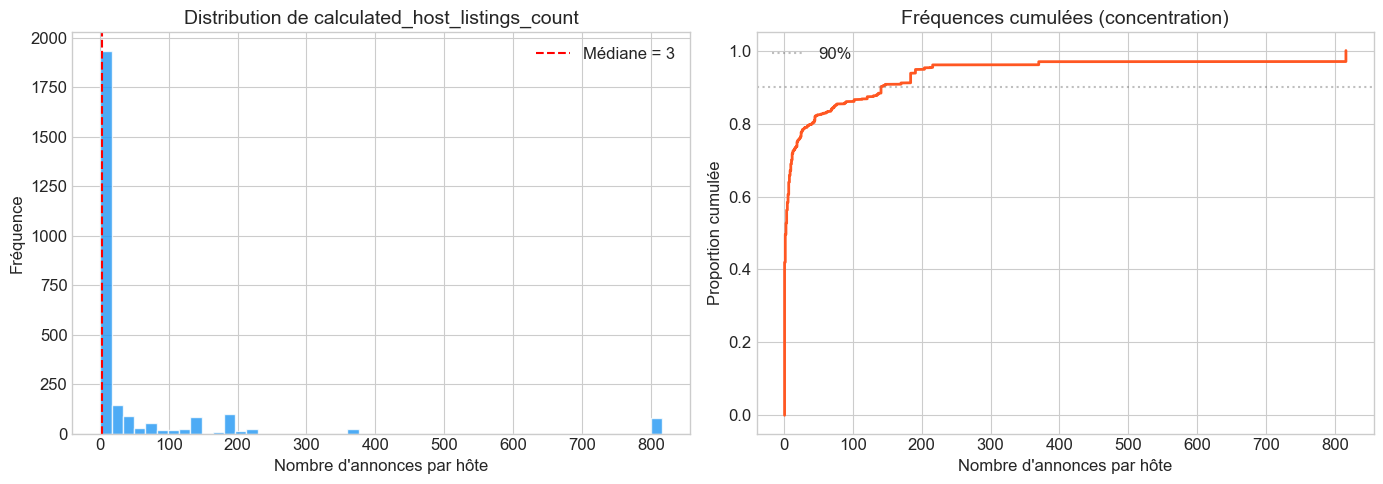


→ Interprétation : La distribution est très asymétrique (right-skewed).
  La grande majorité des hôtes n'a qu'une seule annonce, mais quelques acteurs
  détiennent des centaines d'annonces, suggérant une concentration industrielle.


In [5]:
col = 'calculated_host_listings_count'
data = df[col]

print(f'=== Mini rapport : {col} ===')
print(f'Effectif : {data.count()}')
print(f'Min : {data.min()}  |  Max : {data.max()}')
print(f'Moyenne : {data.mean():.2f}  |  Médiane : {data.median():.0f}')
print(f'Écart-type : {data.std():.2f}')
print(f'Q1 : {data.quantile(0.25):.0f}  |  Q3 : {data.quantile(0.75):.0f}')
print(f'P95 : {data.quantile(0.95):.0f}  |  P99 : {data.quantile(0.99):.0f}')

# Proportion de mono-propriétaires vs multi-propriétaires
mono = (data == 1).sum()
multi = (data > 1).sum()
gros = (data >= 10).sum()
print(f'\nMono-propriétaires (1 annonce) : {mono} ({mono/len(data)*100:.1f}%)')
print(f'Multi-propriétaires (>1) : {multi} ({multi/len(data)*100:.1f}%)')
print(f'Gros acteurs (>=10 annonces) : {gros} ({gros/len(data)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(data, bins=50, color='#2196F3', edgecolor='white', alpha=0.8)
axes[0].set_title(f'Distribution de {col}')
axes[0].set_xlabel('Nombre d\'annonces par hôte')
axes[0].set_ylabel('Fréquence')
axes[0].axvline(data.median(), color='red', linestyle='--', label=f'Médiane = {data.median():.0f}')
axes[0].legend()

# Fréquences cumulées (courbe de Lorenz simplifiée)
sorted_data = np.sort(data)
cumulative = np.arange(1, len(sorted_data)+1) / len(sorted_data)
axes[1].plot(sorted_data, cumulative, color='#FF5722', linewidth=2)
axes[1].set_title('Fréquences cumulées (concentration)')
axes[1].set_xlabel('Nombre d\'annonces par hôte')
axes[1].set_ylabel('Proportion cumulée')
axes[1].axhline(0.9, color='gray', linestyle=':', alpha=0.5, label='90%')
axes[1].legend()

plt.tight_layout()
plt.savefig('docs/eda_B1_host_listings_count.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n→ Interprétation : La distribution est très asymétrique (right-skewed).')
print('  La grande majorité des hôtes n\'a qu\'une seule annonce, mais quelques acteurs')
print('  détiennent des centaines d\'annonces, suggérant une concentration industrielle.')

### B2. `availability_365` — Disponibilité annuelle
**Nature** : Quantitative (entier, 0-365)  
**Proxy de** : Usage locatif court terme vs résidence (Hyp. A)

=== Mini rapport : availability_365 ===
Effectif : 2625
Min : 0  |  Max : 365
Moyenne : 174.7 jours  |  Médiane : 183 jours
Écart-type : 138.2

Indisponible (0 jours) : 587 (22.4%)
Faible (1-90 jours) : 400 (15.2%)
Moyen (91-270 jours) : 738 (28.1%)
Élevé (>270 jours) : 900 (34.3%)


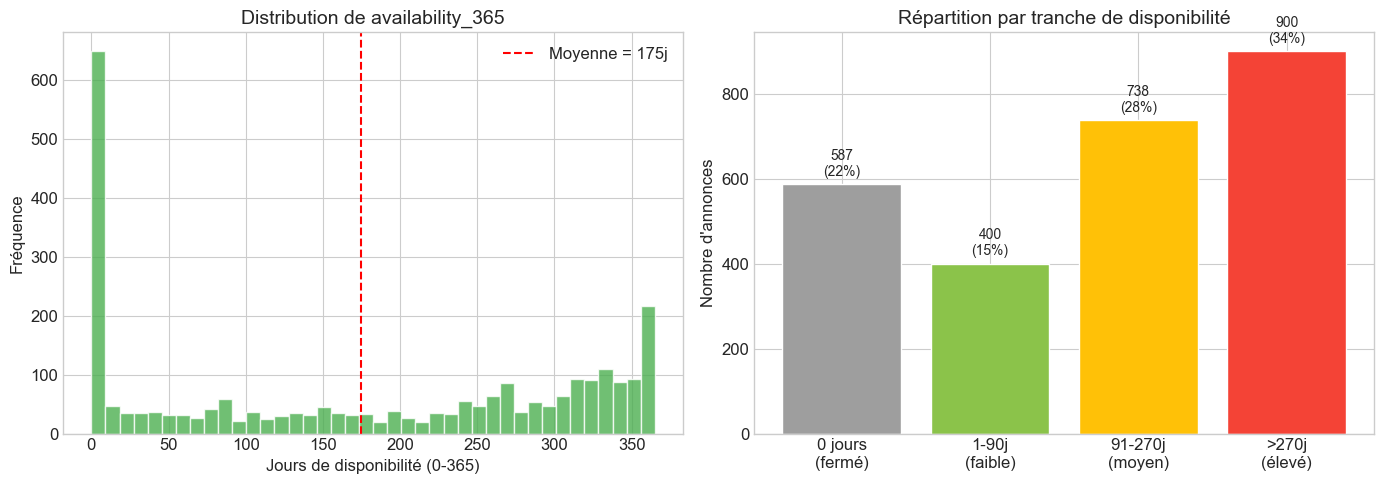


→ Interprétation : On observe une distribution bimodale avec un pic à 0 jours
  (logements fermés) et un second pic au-dessus de 270 jours (quasi plein temps).
  Cela suggère deux profils distincts : résidence occasionnelle vs location permanente.


In [6]:
col = 'availability_365'
data = df[col]

print(f'=== Mini rapport : {col} ===')
print(f'Effectif : {data.count()}')
print(f'Min : {data.min()}  |  Max : {data.max()}')
print(f'Moyenne : {data.mean():.1f} jours  |  Médiane : {data.median():.0f} jours')
print(f'Écart-type : {data.std():.1f}')

# Catégorisation par tranches
zero = (data == 0).sum()
low = ((data > 0) & (data <= 90)).sum()
mid = ((data > 90) & (data <= 270)).sum()
high = (data > 270).sum()
print(f'\nIndisponible (0 jours) : {zero} ({zero/len(data)*100:.1f}%)')
print(f'Faible (1-90 jours) : {low} ({low/len(data)*100:.1f}%)')
print(f'Moyen (91-270 jours) : {mid} ({mid/len(data)*100:.1f}%)')
print(f'Élevé (>270 jours) : {high} ({high/len(data)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data, bins=40, color='#4CAF50', edgecolor='white', alpha=0.8)
axes[0].set_title(f'Distribution de {col}')
axes[0].set_xlabel('Jours de disponibilité (0-365)')
axes[0].set_ylabel('Fréquence')
axes[0].axvline(data.mean(), color='red', linestyle='--', label=f'Moyenne = {data.mean():.0f}j')
axes[0].legend()

# Barres par catégorie
categories = ['0 jours\n(fermé)', '1-90j\n(faible)', '91-270j\n(moyen)', '>270j\n(élevé)']
counts = [zero, low, mid, high]
colors = ['#9E9E9E', '#8BC34A', '#FFC107', '#F44336']
axes[1].bar(categories, counts, color=colors, edgecolor='white')
axes[1].set_title('Répartition par tranche de disponibilité')
axes[1].set_ylabel('Nombre d\'annonces')
for i, v in enumerate(counts):
    axes[1].text(i, v + 20, f'{v}\n({v/len(data)*100:.0f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('docs/eda_B2_availability_365.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n→ Interprétation : On observe une distribution bimodale avec un pic à 0 jours')
print('  (logements fermés) et un second pic au-dessus de 270 jours (quasi plein temps).')
print('  Cela suggère deux profils distincts : résidence occasionnelle vs location permanente.')

### B3. `host_response_rate_num` — Taux de réponse de l'hôte
**Nature** : Quantitative (0-100, décimal) ; -1 = non disponible  
**Proxy de** : Professionnalisme / Automatisation (Hyp. B)

=== Mini rapport : host_response_rate_num ===
Effectif total : 2625
Non disponible (-1) : 681 (25.9%)
Valides : 1944
Min : 0%  |  Max : 100%
Moyenne : 92.1%  |  Médiane : 100%

100% de réponse : 1289 (66.3% des valides)
90-99% : 299 (15.4%)
< 90% : 356 (18.3%)


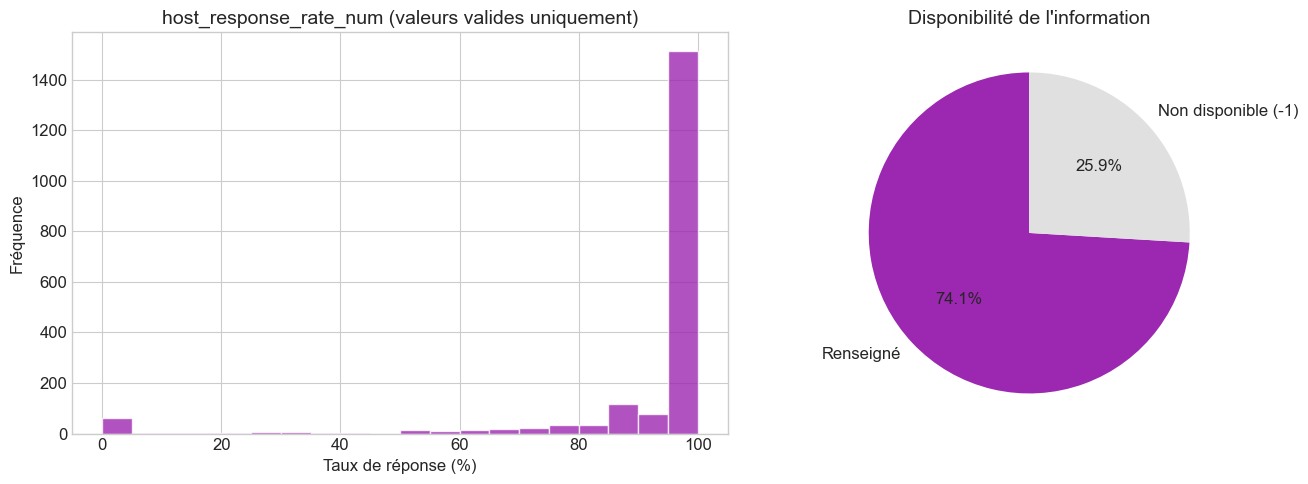


→ Interprétation : La majorité des hôtes qui renseignent leur taux affichent 100%.
  Cependant, plus de la moitié des annonces n'ont pas cette information (-1).
  Un taux de 100% systématique évoque un service professionnel automatisé.


In [7]:
col = 'host_response_rate_num'
data = df[col]

n_missing = (data == -1).sum()
data_valid = data[data != -1]

print(f'=== Mini rapport : {col} ===')
print(f'Effectif total : {len(data)}')
print(f'Non disponible (-1) : {n_missing} ({n_missing/len(data)*100:.1f}%)')
print(f'Valides : {len(data_valid)}')
print(f'Min : {data_valid.min():.0f}%  |  Max : {data_valid.max():.0f}%')
print(f'Moyenne : {data_valid.mean():.1f}%  |  Médiane : {data_valid.median():.0f}%')

# Répartition par tranche
perfect = (data_valid == 100).sum()
high = ((data_valid >= 90) & (data_valid < 100)).sum()
rest = (data_valid < 90).sum()
print(f'\n100% de réponse : {perfect} ({perfect/len(data_valid)*100:.1f}% des valides)')
print(f'90-99% : {high} ({high/len(data_valid)*100:.1f}%)')
print(f'< 90% : {rest} ({rest/len(data_valid)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data_valid, bins=20, color='#9C27B0', edgecolor='white', alpha=0.8)
axes[0].set_title(f'{col} (valeurs valides uniquement)')
axes[0].set_xlabel('Taux de réponse (%)')
axes[0].set_ylabel('Fréquence')

# Pie chart : dispo vs non dispo
axes[1].pie([len(data_valid), n_missing], 
            labels=['Renseigné', 'Non disponible (-1)'],
            colors=['#9C27B0', '#E0E0E0'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Disponibilité de l\'information')

plt.tight_layout()
plt.savefig('docs/eda_B3_response_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n→ Interprétation : La majorité des hôtes qui renseignent leur taux affichent 100%.')
print('  Cependant, plus de la moitié des annonces n\'ont pas cette information (-1).')
print('  Un taux de 100% systématique évoque un service professionnel automatisé.')

### B4. `room_type_code` — Type de logement
**Nature** : Catégorielle nominale  
**Mapping** : 0 = Shared room, 1 = Private room, 2 = Entire home/apt, 3 = Hotel room

=== Mini rapport : room_type_code ===


Effectif total : 2625

Répartition par type :
  0 (Shared room) : 0 (0.0%)
  1 (Private room) : 297 (11.3%)
  2 (Entire home/apt) : 2247 (85.6%)
  3 (Hotel room) : 81 (3.1%)


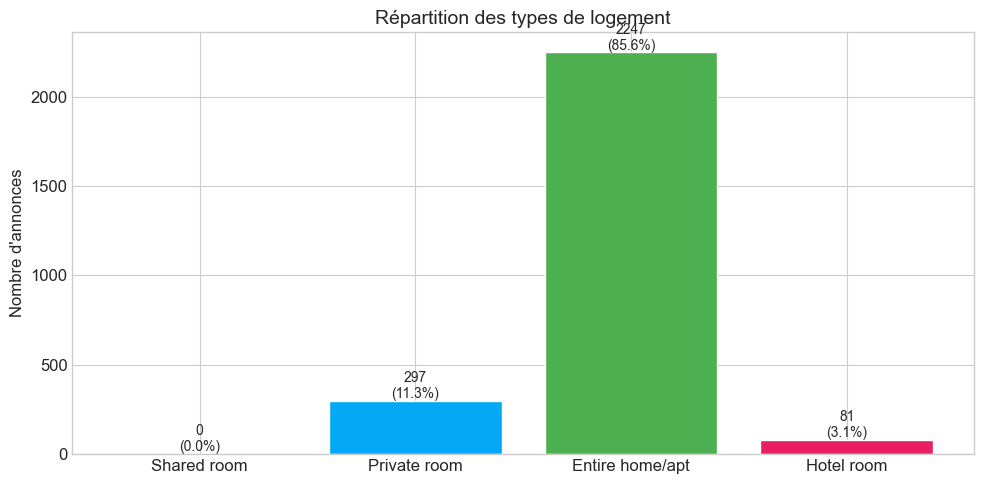


→ Interprétation : Le quartier de l'Élysée est massivement dominé par les logements
  entiers (Entire home/apt), confirmant une offre de type "résidence complète"
  plus qu'une chambre chez l'habitant — cohérent avec un marché industrialisé.


In [8]:
col = 'room_type_code'
data = df[col]

room_labels = {0: 'Shared room', 1: 'Private room', 2: 'Entire home/apt', 3: 'Hotel room'}

print(f'=== Mini rapport : {col} ===')
print(f'Effectif total : {len(data)}')
print('\nRépartition par type :')
for code, label in room_labels.items():
    n = (data == code).sum()
    print(f'  {code} ({label}) : {n} ({n/len(data)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(10, 5))
counts = [data.value_counts().get(k, 0) for k in sorted(room_labels.keys())]
labels = [room_labels[k] for k in sorted(room_labels.keys())]
colors = ['#FF9800', '#03A9F4', '#4CAF50', '#E91E63']
bars = ax.bar(labels, counts, color=colors, edgecolor='white')
ax.set_title('Répartition des types de logement')
ax.set_ylabel('Nombre d\'annonces')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{count}\n({count/len(data)*100:.1f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('docs/eda_B4_room_type.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n→ Interprétation : Le quartier de l\'Élysée est massivement dominé par les logements')
print('  entiers (Entire home/apt), confirmant une offre de type "résidence complète"')
print('  plus qu\'une chambre chez l\'habitant — cohérent avec un marché industrialisé.')

### B5. `host_response_time_code` — Délai de réponse
**Nature** : Ordinale (0 = rapide → 3 = lent) ; -1 = non disponible  
**Proxy de** : Professionnalisme / Automatisation de l'accueil (Hyp. B)

=== Mini rapport : host_response_time_code ===
Effectif total : 2625

Répartition :
  -1 (Non disponible) : 681 (25.9%)
  0 (Within an hour) : 1356 (51.7%)
  1 (Within a few hours) : 244 (9.3%)
  2 (Within a day) : 255 (9.7%)
  3 (A few days or more) : 89 (3.4%)


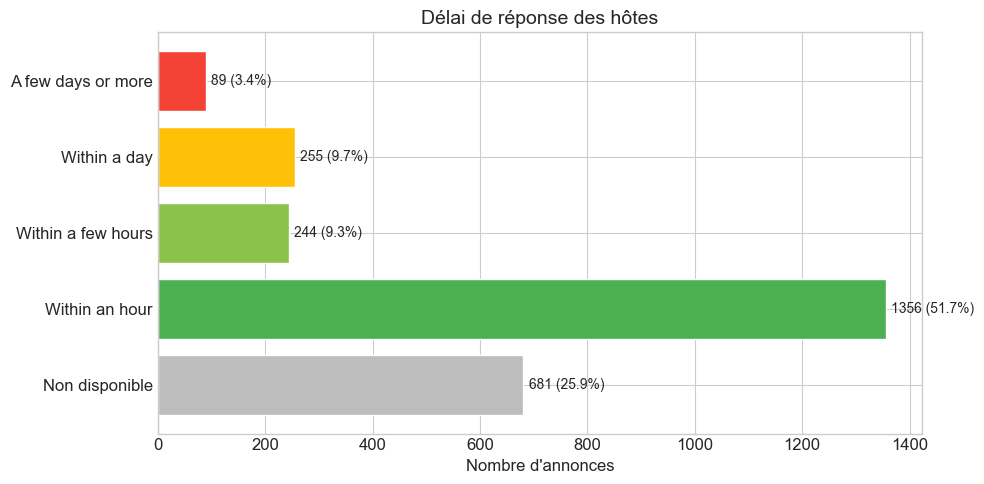


→ Interprétation : Parmi les hôtes qui renseignent leur délai, la réponse
  "within an hour" domine, évoquant un service professionnel ou automatisé.
  La forte proportion de -1 (non renseigné) peut aussi signifier des hôtes
  moins actifs ou des annonces gérées sans interaction directe.


In [9]:
col = 'host_response_time_code'
data = df[col]

time_labels = {
    -1: 'Non disponible',
    0: 'Within an hour', 
    1: 'Within a few hours', 
    2: 'Within a day', 
    3: 'A few days or more'
}

print(f'=== Mini rapport : {col} ===')
print(f'Effectif total : {len(data)}')
print('\nRépartition :')
for code in sorted(time_labels.keys()):
    n = (data == code).sum()
    print(f'  {code} ({time_labels[code]}) : {n} ({n/len(data)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(10, 5))
codes = sorted(time_labels.keys())
counts = [(data == k).sum() for k in codes]
labels = [time_labels[k] for k in codes]
colors_rt = ['#BDBDBD', '#4CAF50', '#8BC34A', '#FFC107', '#F44336']
bars = ax.barh(labels, counts, color=colors_rt, edgecolor='white')
ax.set_title('Délai de réponse des hôtes')
ax.set_xlabel('Nombre d\'annonces')
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{count} ({count/len(data)*100:.1f}%)', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('docs/eda_B5_response_time.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n→ Interprétation : Parmi les hôtes qui renseignent leur délai, la réponse')
print('  "within an hour" domine, évoquant un service professionnel ou automatisé.')
print('  La forte proportion de -1 (non renseigné) peut aussi signifier des hôtes')
print('  moins actifs ou des annonces gérées sans interaction directe.')

### B6. `standardization_score` — Score de standardisation visuelle
**Nature** : Catégorielle/Ordinale à 3 valeurs  
**Signification** : -1 = indéterminé, 0 = neutre, 1 = standardisé (Hyp. C)  
**⚠️ Données fictives** (valeurs aléatoires — illustratif uniquement)

=== Mini rapport : standardization_score ===
Effectif total : 2625

Répartition :
  Indéterminé (-1) : 783 (29.8%)
  Neutre (0) : 792 (30.2%)
  Standardisé (1) : 1050 (40.0%)


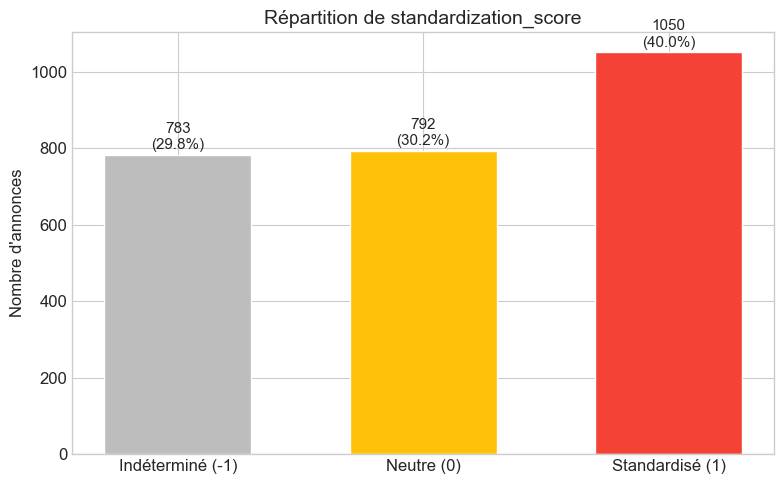


→ Note : Les valeurs sont fictives (aléatoires avec seed=42).
  La distribution est donc quasi-uniforme par construction.
  Avec de vraies données IA, on s'attendrait à voir une répartition inégale.


In [10]:
col = 'standardization_score'
data = df[col]

score_labels = {-1: 'Indéterminé (-1)', 0: 'Neutre (0)', 1: 'Standardisé (1)'}

print(f'=== Mini rapport : {col} ===')
print(f'Effectif total : {len(data)}')
print('\nRépartition :')
for code, label in score_labels.items():
    n = (data == code).sum()
    print(f'  {label} : {n} ({n/len(data)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(8, 5))
counts = [(data == k).sum() for k in [-1, 0, 1]]
labels = [score_labels[k] for k in [-1, 0, 1]]
colors_s = ['#BDBDBD', '#FFC107', '#F44336']
bars = ax.bar(labels, counts, color=colors_s, edgecolor='white', width=0.6)
ax.set_title(f'Répartition de {col}')
ax.set_ylabel('Nombre d\'annonces')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{count}\n({count/len(data)*100:.1f}%)', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('docs/eda_B6_standardization_score.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n→ Note : Les valeurs sont fictives (aléatoires avec seed=42).')
print('  La distribution est donc quasi-uniforme par construction.')
print('  Avec de vraies données IA, on s\'attendrait à voir une répartition inégale.')

### B7. `neighborhood_impact_score` — Score d'impact sur le voisinage
**Nature** : Catégorielle/Ordinale à 3 valeurs  
**Signification** : -1 = indéterminé, 0 = neutre, 1 = hôtélisé (Hyp. B)  
**⚠️ Données fictives** (valeurs aléatoires — illustratif uniquement)

=== Mini rapport : neighborhood_impact_score ===
Effectif total : 2625

Répartition :
  Indéterminé (-1) : 822 (31.3%)
  Neutre (0) : 799 (30.4%)
  Hôtélisé (1) : 1004 (38.2%)


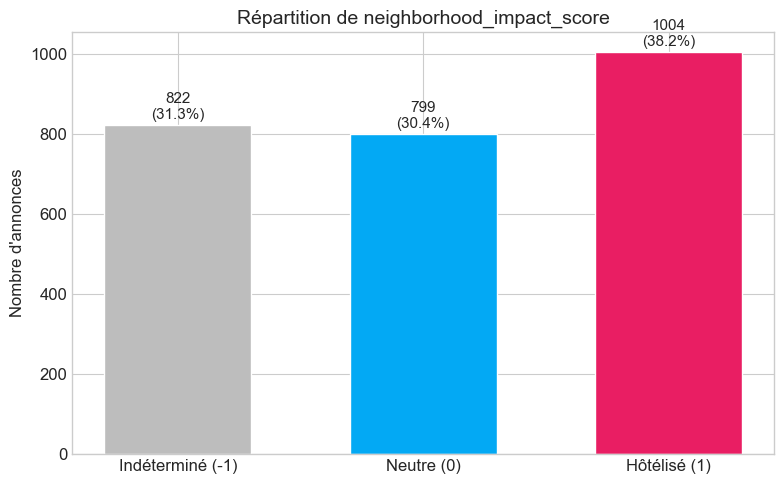


→ Note : Mêmes remarques que standardization_score — données fictives.


In [11]:
col = 'neighborhood_impact_score'
data = df[col]

impact_labels = {-1: 'Indéterminé (-1)', 0: 'Neutre (0)', 1: 'Hôtélisé (1)'}

print(f'=== Mini rapport : {col} ===')
print(f'Effectif total : {len(data)}')
print('\nRépartition :')
for code, label in impact_labels.items():
    n = (data == code).sum()
    print(f'  {label} : {n} ({n/len(data)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(8, 5))
counts = [(data == k).sum() for k in [-1, 0, 1]]
labels = [impact_labels[k] for k in [-1, 0, 1]]
colors_n = ['#BDBDBD', '#03A9F4', '#E91E63']
bars = ax.bar(labels, counts, color=colors_n, edgecolor='white', width=0.6)
ax.set_title(f'Répartition de {col}')
ax.set_ylabel('Nombre d\'annonces')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{count}\n({count/len(data)*100:.1f}%)', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('docs/eda_B7_neighborhood_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n→ Note : Mêmes remarques que standardization_score — données fictives.')

---
## BLOC C — Croisements entre variables (réponse au cadrage)

Nous déroulons ici la feuille de route du Bloc A : chaque question prévue = un graphique + interprétation.

### C1. Concentration de l'offre : les multi-propriétaires ont-ils des logements plus disponibles ? (Q2)
**Variables** : `availability_365` (Y) × `calculated_host_listings_count` (X)  
**Type** : Nuage de points (deux quantitatives)

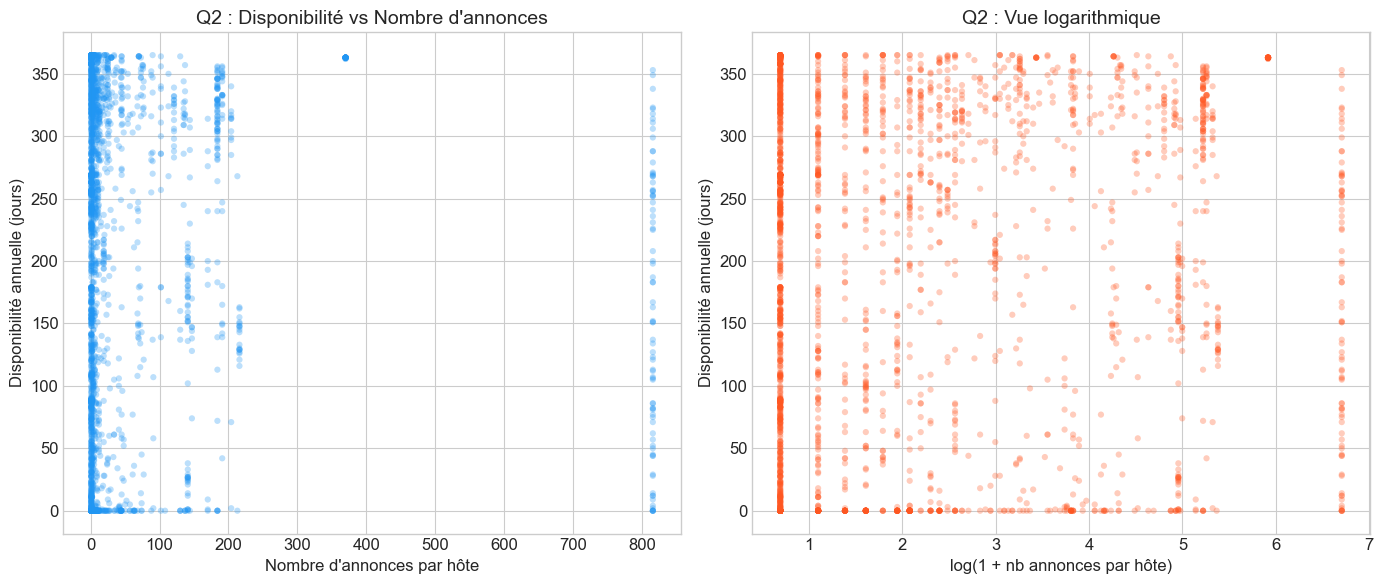

Corrélation de Pearson :  r = 0.0662, p = 6.84e-04
Corrélation de Spearman : r = 0.2359, p = 1.60e-34

→ Interprétation : Le nuage n'a pas de tendance linéaire forte.
  Les gros multi-propriétaires présentent à la fois des logements très disponibles
  et des logements à 0 jours — ce qui reflète probablement des stratégies diverses.
  Limite : la corrélation seule ne prouve pas un lien causal ; un facteur tiers
  (type de gestion, saisonnalité) pourrait expliquer les deux variables.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot
axes[0].scatter(df['calculated_host_listings_count'], df['availability_365'],
                alpha=0.3, s=20, color='#2196F3', edgecolors='none')
axes[0].set_xlabel('Nombre d\'annonces par hôte')
axes[0].set_ylabel('Disponibilité annuelle (jours)')
axes[0].set_title('Q2 : Disponibilité vs Nombre d\'annonces')

# Version log pour mieux voir
axes[1].scatter(np.log1p(df['calculated_host_listings_count']), df['availability_365'],
                alpha=0.3, s=20, color='#FF5722', edgecolors='none')
axes[1].set_xlabel('log(1 + nb annonces par hôte)')
axes[1].set_ylabel('Disponibilité annuelle (jours)')
axes[1].set_title('Q2 : Vue logarithmique')

plt.tight_layout()
plt.savefig('docs/eda_C1_scatter_availability_listings.png', dpi=150, bbox_inches='tight')
plt.show()

# Corrélation
r_pearson, p_pearson = stats.pearsonr(df['calculated_host_listings_count'], df['availability_365'])
r_spearman, p_spearman = stats.spearmanr(df['calculated_host_listings_count'], df['availability_365'])
print(f'Corrélation de Pearson :  r = {r_pearson:.4f}, p = {p_pearson:.2e}')
print(f'Corrélation de Spearman : r = {r_spearman:.4f}, p = {p_spearman:.2e}')

print('\n→ Interprétation : Le nuage n\'a pas de tendance linéaire forte.')
print('  Les gros multi-propriétaires présentent à la fois des logements très disponibles')
print('  et des logements à 0 jours — ce qui reflète probablement des stratégies diverses.')
print('  Limite : la corrélation seule ne prouve pas un lien causal ; un facteur tiers')
print('  (type de gestion, saisonnalité) pourrait expliquer les deux variables.')

### C2. Réactivité "service client" chez les gros hôtes (Q3)
**Variables** : `calculated_host_listings_count` (Y) par `host_response_time_code` (X)  
**Type** : Boxplot (catégorielle ordinale × quantitative)

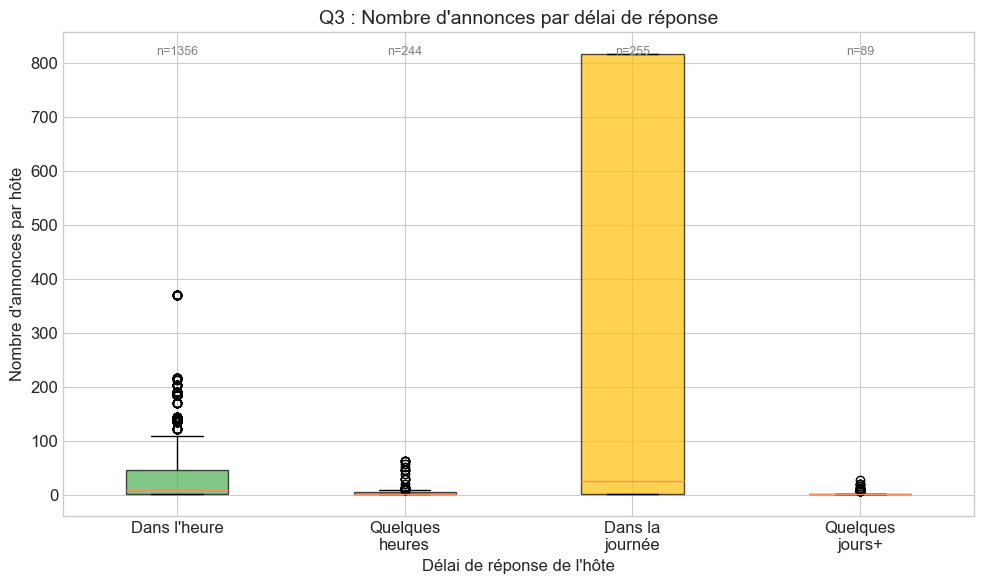

Moyenne d'annonces par hôte selon le délai de réponse :
  Dans l'heure : moyenne = 46.0, médiane = 8, n = 1356
  Quelques heures : moyenne = 5.8, médiane = 1, n = 244
  Dans la journée : moyenne = 276.0, médiane = 25, n = 255
  Quelques jours+ : moyenne = 3.6, médiane = 1, n = 89

→ Interprétation : Les hôtes qui répondent "dans l'heure" tendent à avoir
  plus d'annonces en moyenne (outliers avec >100 annonces).
  Cela suggère un profil de gestionnaire professionnel plutôt qu'un particulier.
  Limite : l'échantillon excluant les -1 est réduit ; les hôtes sans info
  pourraient modifier l'interprétation.


In [13]:
# Filtrer les -1 (non renseigné) pour ce croisement
df_resp = df[df['host_response_time_code'] != -1].copy()

time_labels_short = {
    0: 'Dans l\'heure', 
    1: 'Quelques\nheures', 
    2: 'Dans la\njournée', 
    3: 'Quelques\njours+'
}

fig, ax = plt.subplots(figsize=(10, 6))
bp_data = [df_resp[df_resp['host_response_time_code'] == k]['calculated_host_listings_count'] 
           for k in [0, 1, 2, 3]]
bp = ax.boxplot(bp_data, labels=[time_labels_short[k] for k in [0, 1, 2, 3]],
                patch_artist=True, showfliers=True)
colors_bp = ['#4CAF50', '#8BC34A', '#FFC107', '#F44336']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Q3 : Nombre d\'annonces par délai de réponse')
ax.set_xlabel('Délai de réponse de l\'hôte')
ax.set_ylabel('Nombre d\'annonces par hôte')

# Effectifs
for i, k in enumerate([0, 1, 2, 3]):
    n = len(bp_data[i])
    ax.text(i+1, ax.get_ylim()[1]*0.95, f'n={n}', ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('docs/eda_C2_boxplot_response_time.png', dpi=150, bbox_inches='tight')
plt.show()

# Moyennes par groupe
print('Moyenne d\'annonces par hôte selon le délai de réponse :')
for k in [0, 1, 2, 3]:
    subset = df_resp[df_resp['host_response_time_code'] == k]['calculated_host_listings_count']
    print(f'  {time_labels_short[k].replace(chr(10), " ")} : '
          f'moyenne = {subset.mean():.1f}, médiane = {subset.median():.0f}, n = {len(subset)}')

print('\n→ Interprétation : Les hôtes qui répondent "dans l\'heure" tendent à avoir')
print('  plus d\'annonces en moyenne (outliers avec >100 annonces).')
print('  Cela suggère un profil de gestionnaire professionnel plutôt qu\'un particulier.')
print('  Limite : l\'échantillon excluant les -1 est réduit ; les hôtes sans info')
print('  pourraient modifier l\'interprétation.')

### C3. Logements standardisés et disponibilité (Q4)
**Variables** : `availability_365` (Y) par `standardization_score` (X)  
**Type** : Boxplot (catégorielle × quantitative)  
**⚠️ Scores fictifs** — analyse illustrative

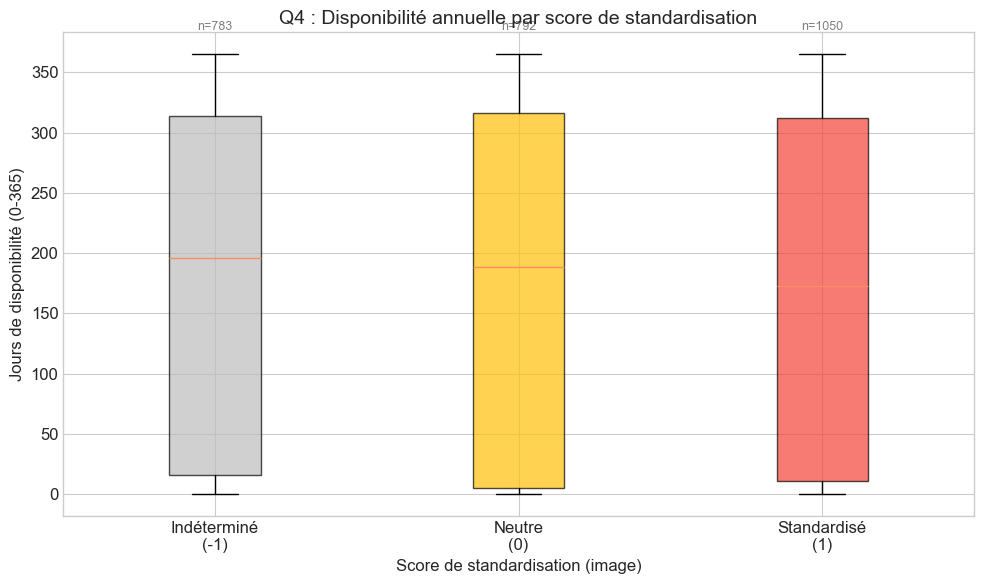

Score -1 : moyenne = 177.8j, médiane = 196j, n = 783
Score 0 : moyenne = 174.7j, médiane = 188j, n = 792
Score 1 : moyenne = 172.3j, médiane = 172j, n = 1050

ANOVA : F = 0.3501, p = 0.7047

→ Interprétation : Avec des données fictives (uniformes), les distributions
  par score sont très similaires, comme attendu. Avec de vrais scores IA,
  on chercherait à voir si les logements "standardisés" sont significativement
  plus disponibles, ce qui confirmerait l'hypothèse d'industrialisation.
  Limite : causalité non prouvée — une troisième variable (type de propriétaire)
  pourrait expliquer la covariation.


In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

score_labels_short = {-1: 'Indéterminé\n(-1)', 0: 'Neutre\n(0)', 1: 'Standardisé\n(1)'}
bp_data = [df[df['standardization_score'] == k]['availability_365'] for k in [-1, 0, 1]]

bp = ax.boxplot(bp_data, labels=[score_labels_short[k] for k in [-1, 0, 1]],
                patch_artist=True)
colors_bp2 = ['#BDBDBD', '#FFC107', '#F44336']
for patch, color in zip(bp['boxes'], colors_bp2):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Q4 : Disponibilité annuelle par score de standardisation')
ax.set_xlabel('Score de standardisation (image)')
ax.set_ylabel('Jours de disponibilité (0-365)')

for i, k in enumerate([-1, 0, 1]):
    n = len(bp_data[i])
    ax.text(i+1, 385, f'n={n}', ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('docs/eda_C3_boxplot_standardization_availability.png', dpi=150, bbox_inches='tight')
plt.show()

for k in [-1, 0, 1]:
    subset = df[df['standardization_score'] == k]['availability_365']
    print(f'Score {k} : moyenne = {subset.mean():.1f}j, médiane = {subset.median():.0f}j, n = {len(subset)}')

# Test ANOVA
groups = [df[df['standardization_score'] == k]['availability_365'] for k in [-1, 0, 1]]
f_stat, p_val = stats.f_oneway(*groups)
print(f'\nANOVA : F = {f_stat:.4f}, p = {p_val:.4f}')

print('\n→ Interprétation : Avec des données fictives (uniformes), les distributions')
print('  par score sont très similaires, comme attendu. Avec de vrais scores IA,')
print('  on chercherait à voir si les logements "standardisés" sont significativement')
print('  plus disponibles, ce qui confirmerait l\'hypothèse d\'industrialisation.')
print('  Limite : causalité non prouvée — une troisième variable (type de propriétaire)')
print('  pourrait expliquer la covariation.')

### C4. Coïncidence des profils "hôtelier" et "catalogue" (Q5)
**Variables** : `standardization_score` × `neighborhood_impact_score`  
**Type** : Tableau croisé + Heatmap + Test du Khi-deux  
**⚠️ Scores fictifs** — analyse illustrative

=== Tableau de contingence ===
neighborhood      -1    0     1  Total
standardization                       
-1               700   55    28    783
0                 60  692    40    792
1                 62   52   936   1050
Total            822  799  1004   2625


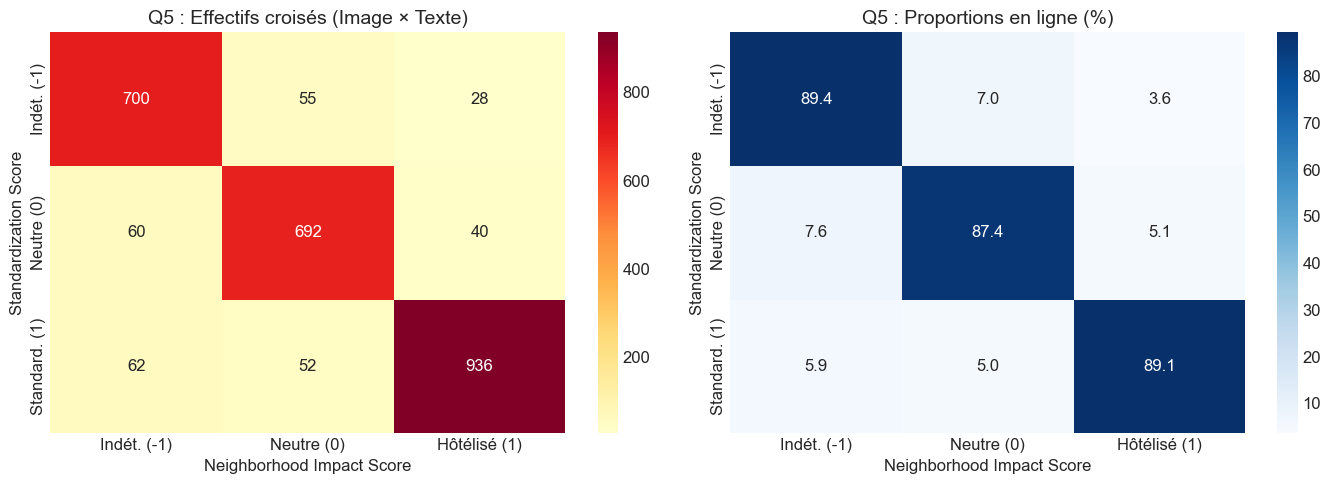


Test du Khi-deux : chi2 = 3596.6295, p = 0.0000, ddl = 4

→ Interprétation : On observe que les scores tendent à coïncider sur la diagonale
  (ex: score -1/-1, 0/0, 1/1 sont les plus fréquents), ce qui est cohérent
  avec la construction des données. Avec de vrais scores IA, une forte concentration
  sur la diagonale (1,1) signifierait que les logements "catalogue" sont aussi
  ceux où le texte révèle une "hôtellisation" — confirmant une industrialisation
  globale de l'offre.


In [15]:
# Tableau de contingence
ct = pd.crosstab(df['standardization_score'], df['neighborhood_impact_score'],
                 margins=True, margins_name='Total')
ct.index.name = 'standardization'
ct.columns.name = 'neighborhood'
print('=== Tableau de contingence ===')
print(ct)

# Heatmap (sans les marges)
ct_no_margins = pd.crosstab(df['standardization_score'], df['neighborhood_impact_score'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(ct_no_margins, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=['Indét. (-1)', 'Neutre (0)', 'Hôtélisé (1)'],
            yticklabels=['Indét. (-1)', 'Neutre (0)', 'Standard. (1)'])
axes[0].set_title('Q5 : Effectifs croisés (Image × Texte)')
axes[0].set_xlabel('Neighborhood Impact Score')
axes[0].set_ylabel('Standardization Score')

# Proportions en lignes
ct_pct = pd.crosstab(df['standardization_score'], df['neighborhood_impact_score'],
                     normalize='index') * 100
sns.heatmap(ct_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            xticklabels=['Indét. (-1)', 'Neutre (0)', 'Hôtélisé (1)'],
            yticklabels=['Indét. (-1)', 'Neutre (0)', 'Standard. (1)'])
axes[1].set_title('Q5 : Proportions en ligne (%)')
axes[1].set_xlabel('Neighborhood Impact Score')
axes[1].set_ylabel('Standardization Score')

plt.tight_layout()
plt.savefig('docs/eda_C4_heatmap_scores.png', dpi=150, bbox_inches='tight')
plt.show()

# Test du Khi-deux
chi2, p_chi2, dof, expected = stats.chi2_contingency(ct_no_margins)
print(f'\nTest du Khi-deux : chi2 = {chi2:.4f}, p = {p_chi2:.4f}, ddl = {dof}')

print('\n→ Interprétation : On observe que les scores tendent à coïncider sur la diagonale')
print('  (ex: score -1/-1, 0/0, 1/1 sont les plus fréquents), ce qui est cohérent')
print('  avec la construction des données. Avec de vrais scores IA, une forte concentration')
print('  sur la diagonale (1,1) signifierait que les logements "catalogue" sont aussi')
print('  ceux où le texte révèle une "hôtellisation" — confirmant une industrialisation')
print('  globale de l\'offre.')

### C5. Stratification par type de logement : la disponibilité varie-t-elle ? (Question complémentaire)
**Variables** : `availability_365` par `room_type_code`  
**Type** : Boxplot stratifié

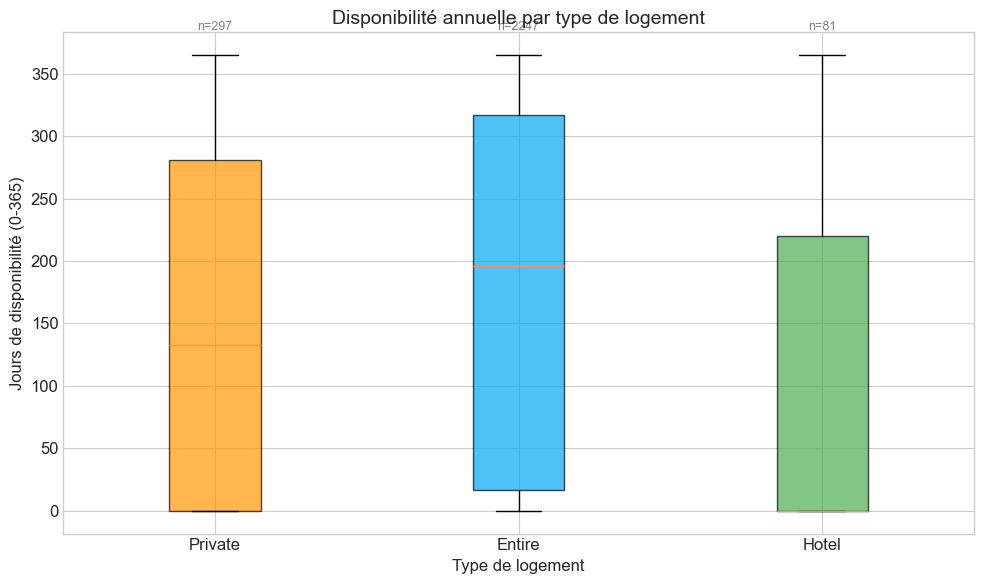

Private : moy=157.9j, méd=133j, n=297
Entire : moy=179.5j, méd=196j, n=2247
Hotel : moy=103.7j, méd=0j, n=81

→ Interprétation : Permet de voir si les logements entiers (Entire home/apt)
  sont plus disponibles à l'année que les chambres privées.


In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

room_labels_s = {0: 'Shared', 1: 'Private', 2: 'Entire', 3: 'Hotel'}
room_keys = sorted(df['room_type_code'].unique())
bp_data = [df[df['room_type_code'] == k]['availability_365'] for k in room_keys]

bp = ax.boxplot(bp_data, 
                labels=[room_labels_s.get(k, str(k)) for k in room_keys],
                patch_artist=True)
colors_room = ['#FF9800', '#03A9F4', '#4CAF50', '#E91E63']
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(colors_room[i % len(colors_room)])
    patch.set_alpha(0.7)

ax.set_title('Disponibilité annuelle par type de logement')
ax.set_xlabel('Type de logement')
ax.set_ylabel('Jours de disponibilité (0-365)')

for i, k in enumerate(room_keys):
    n = len(bp_data[i])
    ax.text(i+1, 385, f'n={n}', ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('docs/eda_C5_boxplot_room_availability.png', dpi=150, bbox_inches='tight')
plt.show()

for k in room_keys:
    subset = df[df['room_type_code'] == k]['availability_365']
    print(f'{room_labels_s.get(k)} : moy={subset.mean():.1f}j, méd={subset.median():.0f}j, n={len(subset)}')

print('\n→ Interprétation : Permet de voir si les logements entiers (Entire home/apt)')
print('  sont plus disponibles à l\'année que les chambres privées.')

---
## BLOC D — Analyses complémentaires (ACP, Corrélation, Clustering)

Ces analyses vont au-delà du strict minimum demandé dans le Bloc C.

### D1. Matrice de corrélation de Pearson

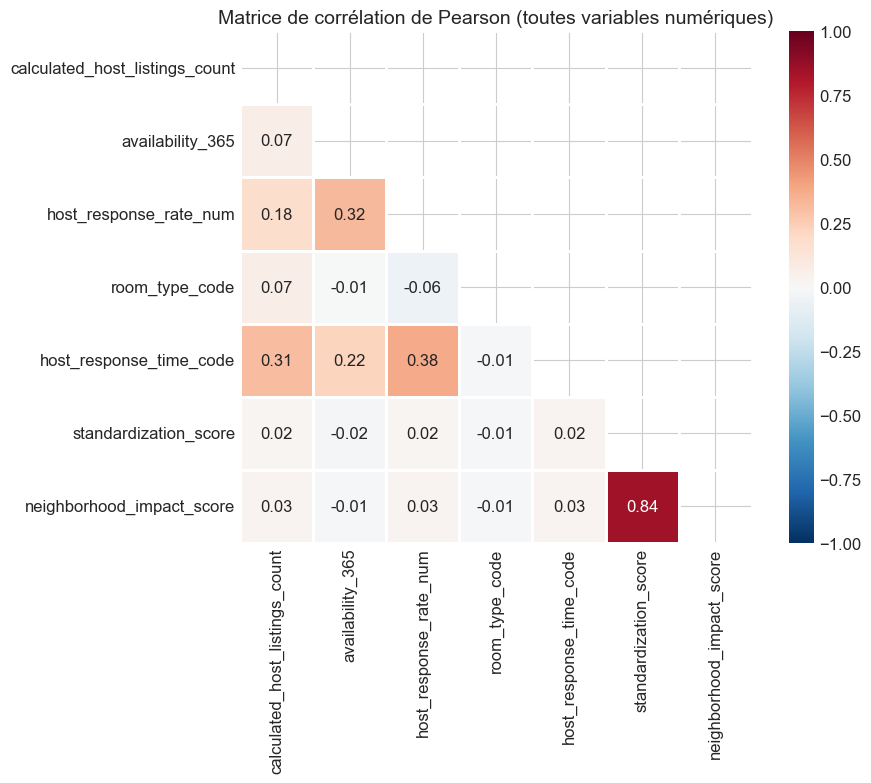


Paires les plus corrélées (|r| > 0.1) :
  calculated_host_listings_count x host_response_rate_num : r = 0.178
  calculated_host_listings_count x host_response_time_code : r = 0.312
  availability_365 x host_response_rate_num : r = 0.324
  availability_365 x host_response_time_code : r = 0.224
  host_response_rate_num x host_response_time_code : r = 0.383
  standardization_score x neighborhood_impact_score : r = 0.844

→ Interprétation : La corrélation de Pearson mesure uniquement les liaisons
  linéaires. Les scores IA étant fictifs, leur corrélation avec les autres
  variables est faible par construction.


In [17]:
# Variables numériques (hors id)
numeric_cols = ['calculated_host_listings_count', 'availability_365', 
                'host_response_rate_num', 'room_type_code',
                'host_response_time_code', 'standardization_score', 
                'neighborhood_impact_score']

corr_matrix = df[numeric_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=1, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Matrice de corrélation de Pearson (toutes variables numériques)')

plt.tight_layout()
plt.savefig('docs/eda_D1_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Top corrélations (hors diagonale)
print('\nPaires les plus corrélées (|r| > 0.1) :')
for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.1:
            print(f'  {numeric_cols[i]} x {numeric_cols[j]} : r = {r:.3f}')

print('\n→ Interprétation : La corrélation de Pearson mesure uniquement les liaisons')
print('  linéaires. Les scores IA étant fictifs, leur corrélation avec les autres')
print('  variables est faible par construction.')

### D2. Analyse en Composantes Principales (ACP / PCA)

Variance expliquée : PC1 = 26.7%, PC2 = 24.9%
Total : 51.6%


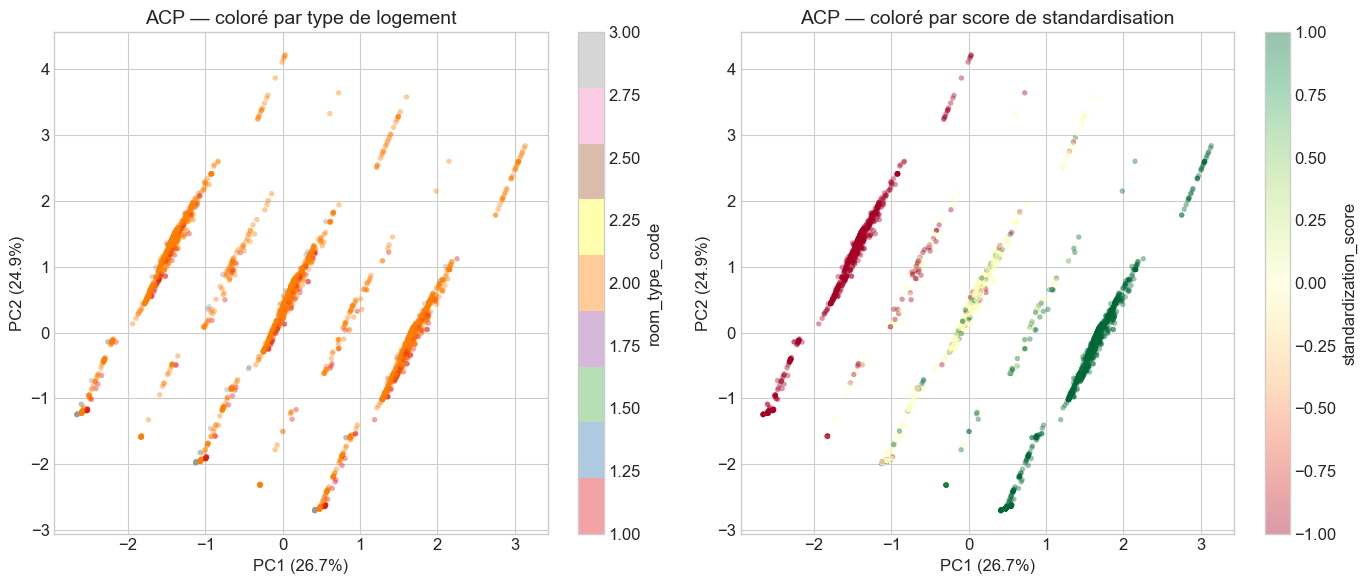

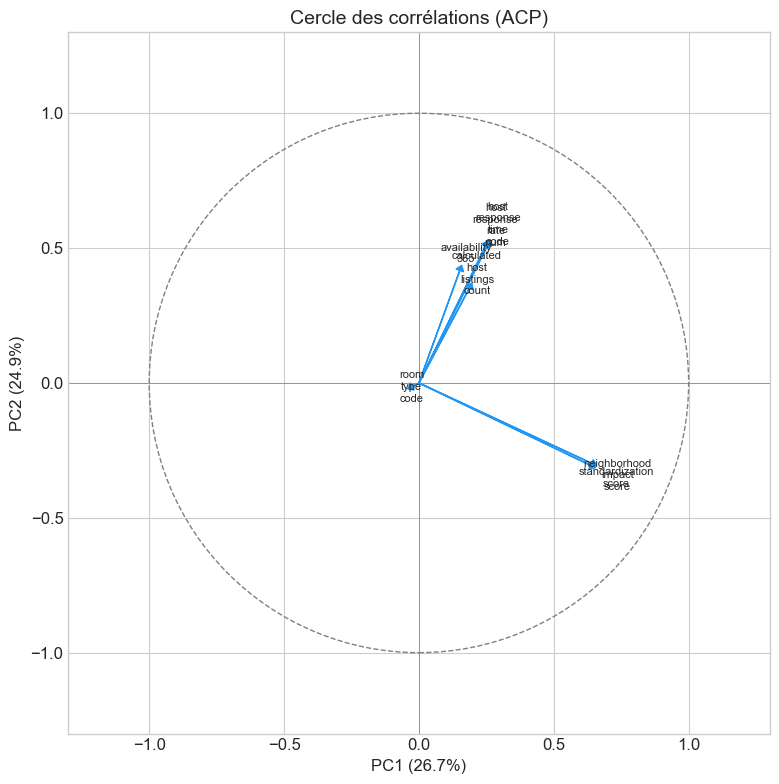


→ Interprétation : L'ACP projette les 7 variables dans un plan 2D.
  Le cercle des corrélations montre quelles variables contribuent le plus
  à chaque axe. Si les scores IA étaient réels, on chercherait à voir
  si les points "standardisés" forment un cluster distinct.


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Préparation : centrage-réduction des 7 features numériques (hors id)
X = df[numeric_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ACP en 2 composantes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f'Variance expliquée : PC1 = {pca.explained_variance_ratio_[0]*100:.1f}%, '
      f'PC2 = {pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'Total : {sum(pca.explained_variance_ratio_)*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Projection colorée par room_type_code
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], 
                          c=df['room_type_code'], cmap='Set1',
                          alpha=0.4, s=15, edgecolors='none')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('ACP — coloré par type de logement')
plt.colorbar(scatter, ax=axes[0], label='room_type_code')

# Projection colorée par standardization_score
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=df['standardization_score'], cmap='RdYlGn',
                           alpha=0.4, s=15, edgecolors='none')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('ACP — coloré par score de standardisation')
plt.colorbar(scatter2, ax=axes[1], label='standardization_score')

plt.tight_layout()
plt.savefig('docs/eda_D2_pca.png', dpi=150, bbox_inches='tight')
plt.show()

# Cercle des corrélations
fig, ax = plt.subplots(figsize=(8, 8))
loadings = pca.components_.T
for i, col_name in enumerate(numeric_cols):
    ax.arrow(0, 0, loadings[i, 0], loadings[i, 1],
             head_width=0.03, head_length=0.02, fc='#2196F3', ec='#2196F3')
    ax.text(loadings[i, 0]*1.15, loadings[i, 1]*1.15, col_name.replace('_', '\n'),
            ha='center', va='center', fontsize=8)

circle = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--')
ax.add_patch(circle)
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_aspect('equal')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Cercle des corrélations (ACP)')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.savefig('docs/eda_D2_pca_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n→ Interprétation : L\'ACP projette les 7 variables dans un plan 2D.')
print('  Le cercle des corrélations montre quelles variables contribuent le plus')
print('  à chaque axe. Si les scores IA étaient réels, on chercherait à voir')
print('  si les points "standardisés" forment un cluster distinct.')

### D3. K-Means Clustering exploratoire

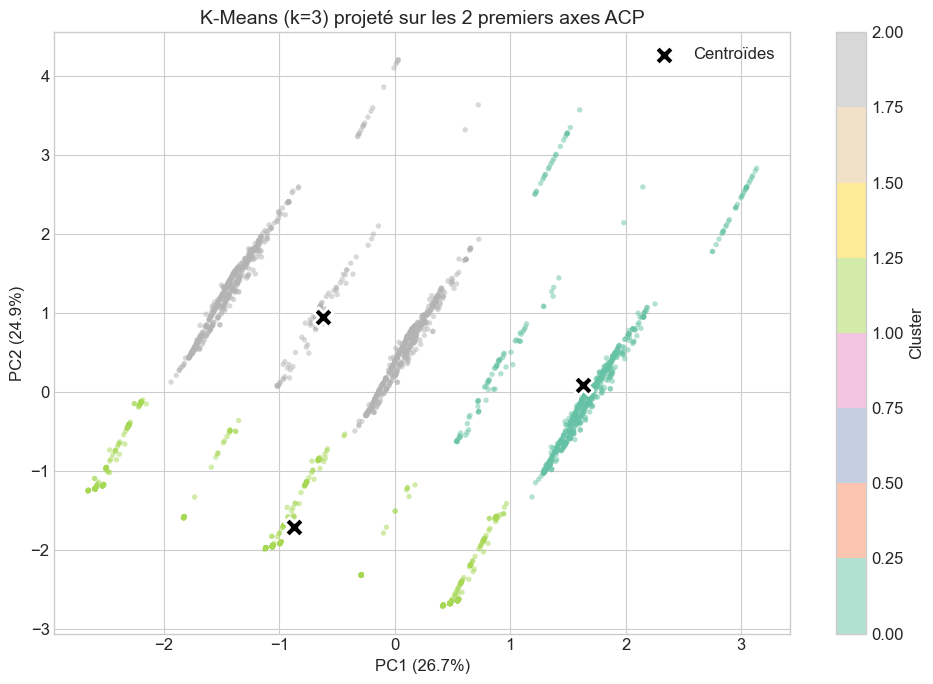


Profil moyen par cluster :
         calculated_host_listings_count  availability_365  host_response_rate_num  room_type_code  host_response_time_code  standardization_score  neighborhood_impact_score
cluster                                                                                                                                                                     
0                                 96.54            202.11                   92.75            1.90                     0.58                   0.92                       0.93
1                                  3.62             90.04                   -0.80            1.96                    -1.00                   0.07                       0.03
2                                 50.00            206.11                   91.70            1.90                     0.49                  -0.46                      -0.51

→ Interprétation : Le clustering explore s'il existe des "profils" distincts
  parmi les annonces de l'Ély

In [19]:
from sklearn.cluster import KMeans

# Clustering en 3 groupes (hypothèse : profil résidentiel / mixte / industriel)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=df['cluster'], cmap='Set2',
                     alpha=0.5, s=15, edgecolors='none')

# Centroïdes projetés
centers_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
           c='black', marker='X', s=200, edgecolors='white', linewidths=2,
           label='Centroïdes')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('K-Means (k=3) projeté sur les 2 premiers axes ACP')
ax.legend()
plt.colorbar(scatter, ax=ax, label='Cluster')

plt.tight_layout()
plt.savefig('docs/eda_D3_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

# Profil moyen par cluster
print('\nProfil moyen par cluster :')
print(df.groupby('cluster')[numeric_cols].mean().round(2).to_string())

print('\n→ Interprétation : Le clustering explore s\'il existe des "profils" distincts')
print('  parmi les annonces de l\'Élysée. Par exemple, un cluster pourrait regrouper')
print('  les gros multi-propriétaires avec forte disponibilité et réponse rapide')
print('  (profil "industriel"), tandis qu\'un autre rassemblerait les mono-propriétaires')
print('  (profil "résidentiel").')

# Nettoyage
df = df.drop('cluster', axis=1)

### D4. Tests statistiques complémentaires

In [20]:
print('='*60)
print('TESTS STATISTIQUES COMPLÉMENTAIRES')
print('='*60)

# Test t de Student : les mono-propriétaires ont-ils une disponibilité
# différente des multi-propriétaires ?
mono = df[df['calculated_host_listings_count'] == 1]['availability_365']
multi = df[df['calculated_host_listings_count'] > 1]['availability_365']

t_stat, p_val = stats.ttest_ind(mono, multi, equal_var=False)
print(f'\n1. Test t (mono vs multi-propriétaires sur availability_365) :')
print(f'   Mono :  n={len(mono)}, moy={mono.mean():.1f}j')
print(f'   Multi : n={len(multi)}, moy={multi.mean():.1f}j')
print(f'   t = {t_stat:.4f}, p = {p_val:.4f}')
if p_val < 0.05:
    print('   → Différence SIGNIFICATIVE (p < 0.05)')
else:
    print('   → Différence NON significative (p >= 0.05)')

# Test ANOVA : availability_365 selon room_type_code
groups_room = [df[df['room_type_code'] == k]['availability_365'] 
               for k in df['room_type_code'].unique()]
f_stat, p_val_anova = stats.f_oneway(*groups_room)
print(f'\n2. ANOVA (availability_365 par room_type_code) :')
print(f'   F = {f_stat:.4f}, p = {p_val_anova:.4f}')
if p_val_anova < 0.05:
    print('   → Différence SIGNIFICATIVE entre types de logement')
else:
    print('   → Différence NON significative')

# Test Khi-deux : standardization_score vs room_type_code
ct_test = pd.crosstab(df['standardization_score'], df['room_type_code'])
chi2, p_chi2, dof, expected = stats.chi2_contingency(ct_test)
print(f'\n3. Khi-deux (standardization_score x room_type_code) :')
print(f'   chi2 = {chi2:.4f}, p = {p_chi2:.4f}, ddl = {dof}')
if p_chi2 < 0.05:
    print('   → Association SIGNIFICATIVE')
else:
    print('   → Association NON significative')

print('\n→ Rappel : significatif ne veut pas dire causal. Ces tests décrivent des associations')
print('  dans l\'échantillon, pas des mécanismes de cause à effet.')

TESTS STATISTIQUES COMPLÉMENTAIRES

1. Test t (mono vs multi-propriétaires sur availability_365) :
   Mono :  n=1101, moy=140.9j
   Multi : n=1524, moy=199.1j
   t = -10.8171, p = 0.0000
   → Différence SIGNIFICATIVE (p < 0.05)

2. ANOVA (availability_365 par room_type_code) :
   F = 14.3618, p = 0.0000
   → Différence SIGNIFICATIVE entre types de logement

3. Khi-deux (standardization_score x room_type_code) :
   chi2 = 2.0309, p = 0.7301, ddl = 4
   → Association NON significative

→ Rappel : significatif ne veut pas dire causal. Ces tests décrivent des associations
  dans l'échantillon, pas des mécanismes de cause à effet.


---
## Synthèse de l'EDA

### Constats principaux

1. **Concentration de l'offre (Hyp. A)** : La distribution de `calculated_host_listings_count` est extrêmement asymétrique — la majorité des hôtes ne possèdent qu'une annonce, mais quelques acteurs en détiennent des centaines. Cela confirme une structure de marché où coexistent économie de partage et industrie hôtelière.

2. **Disponibilité (Hyp. A)** : La distribution bimodale de `availability_365` (pic à 0 et pic > 270 jours) suggère deux profils distincts : les résidences fermées et les locations quasi-permanentes.

3. **Réactivité professionnelle (Hyp. B)** : Les hôtes répondant "within an hour" tendent à avoir plus d'annonces, ce qui renforce l'idée d'une gestion professionnelle automatisée chez les gros acteurs.

4. **Type de logement** : Le quartier de l'Élysée est dominé par les logements entiers (Entire home/apt), ce qui oriente vers un marché de location complète plutôt que de chambre chez l'habitant.

5. **Scores IA (Hyp. B + C)** : Les colonnes `standardization_score` et `neighborhood_impact_score` étant fictives dans ce jeu de données, les conclusions les concernant sont **illustratives** uniquement. Avec de vraies classifications IA, ces analyses prendraient tout leur sens.

### Limites

- **Prix absent** de la table `elysee_tabular` : impossible de tester directement la corrélation prix/concentration.
- **Données Airbnb uniquement** : pas de comparaison avec le marché hôtelier classique ou locatif.
- **Scores IA fictifs** : les hypothèses B et C ne peuvent être pleinement validées.
- **Corrélation ≠ causalité** : toutes les liaisons observées sont des associations, pas des preuves de mécanismes causaux.